# EE446 - TinyML - Assignment 2

## Importing Libraries

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from pylab import rcParams
from sklearn.model_selection import train_test_split
from tensorflow.keras import datasets, layers,models
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Activation
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
from tensorflow.keras import regularizers
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score
import c_writer
from os.path import join

2026-05-30 11:11:01.507571: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-30 11:11:01.508836: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-30 11:11:01.528467: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-30 11:11:01.528483: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-30 11:11:01.528498: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

## Reading Data

In [3]:
# Reading the data and adding column header (feature) names
data = pd.read_csv("Network_anomaly_data.txt",sep=",",names=["duration","protocoltype","service",
"flag","srcbytes","dstbytes","land", "wrongfragment","urgent","hot","numfailedlogins","loggedin", "numcompromised",
"rootshell","suattempted","numroot","numfilecreations", "numshells","numaccessfiles","numoutboundcmds","ishostlogin",
"isguestlogin","count","srvcount","serrorrate", "srvserrorrate","rerrorrate","srvrerrorrate","samesrvrate",
"diffsrvrate", "srvdiffhostrate","dsthostcount","dsthostsrvcount","dsthostsamesrvrate", "dsthostdiffsrvrate",
"dsthostsamesrcportrate","dsthostsrvdiffhostrate","dsthostserrorrate","dsthostsrvserrorrate","dsthostrerrorrate",
"dsthostsrvrerrorrate","attack", "lastflag"])

In [4]:
data # printing the dataframe

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


## Question 1: Data Preprocessing

##### (a) Drop the 'land', 'urgent', 'numfailedlogins', 'numoutboundcmds' columns from the dataframe "data".

In [5]:
# Drop the specified columns that are not needed
data = data.drop(['land', 'urgent', 'numfailedlogins', 'numoutboundcmds'], axis=1)

##### (b) Change any label that is not named normal to attack in the {'attack'} column of the dataframe data.

In [6]:
# Map all non-'normal' labels to 'attack' in the 'attack' column
data['attack'] = data['attack'].apply(lambda x: 'normal' if str(x).strip() == 'normal' else 'attack')

In [7]:
data #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,19
3,0,tcp,http,SF,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,attack,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,20


##### (c) Use LabelEncoder() function from the sklearn.preprocessing library to convert non-numerical attributes in the {'protocoltype', 'service', 'flag', 'attack'} columns of the dataframe data to numerical values.

In [8]:
cols_to_encode = ['protocoltype', 'service', 'flag', 'attack']
for col in cols_to_encode:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

In [9]:
pd.DataFrame(data) #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,19
3,0,1,24,9,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1,21
4,0,1,24,9,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,1,49,5,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,0,20
125969,8,2,49,9,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,1,21
125970,0,1,54,9,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,1,18
125971,0,1,30,5,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,20


## Feature Scaling and Train/Test Split

In [10]:
# All the features apart from Attack are what we are going to use to predict the attack status of the data
# attack = 1 (normal/not an attack) and attack = 0 (attack)
X = data.drop(['attack'],axis=1).to_numpy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_normalized = scaler.fit_transform(X)

Y = data['attack'].to_numpy()
# Splitting X and y testing and training data
# we are taking 20% of the data for testing and 80% of the data for training
X_train, X_test, y_train, y_test = train_test_split(X_normalized, Y, test_size = 0.20)
# reshaping y test and train array
y_train = y_train.reshape(len(y_train),1)
y_test = y_test.reshape(len(y_test),1)

## Question 2: Dimensionality Reduction for Visualization

##### (a) Use TSNE from the sklearn.manifold library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

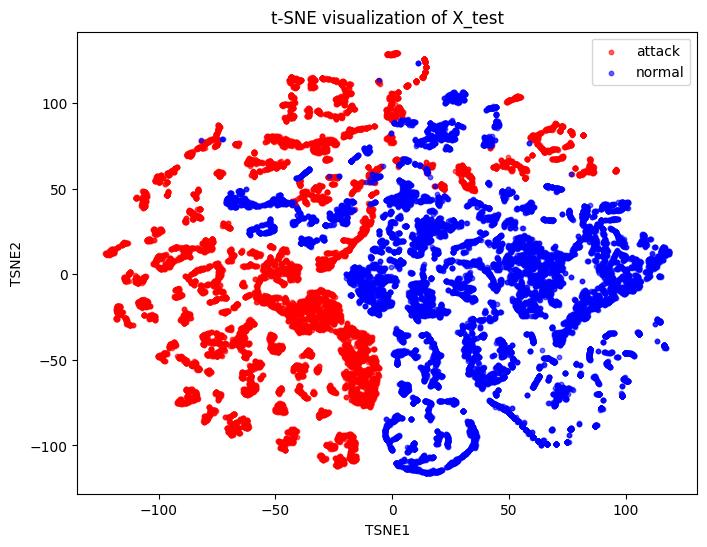

In [11]:
from sklearn.manifold import TSNE
y = y_test.flatten()
tsne = TSNE(n_components=2, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X_test)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[y==0,0], X_tsne[y==0,1], c='red', label='attack', alpha=0.6, s=10)
plt.scatter(X_tsne[y==1,0], X_tsne[y==1,1], c='blue', label='normal', alpha=0.6, s=10)
plt.legend()
plt.title('t-SNE visualization of X_test')
plt.xlabel('TSNE1')
plt.ylabel('TSNE2')
plt.show()

##### (b) Use PCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

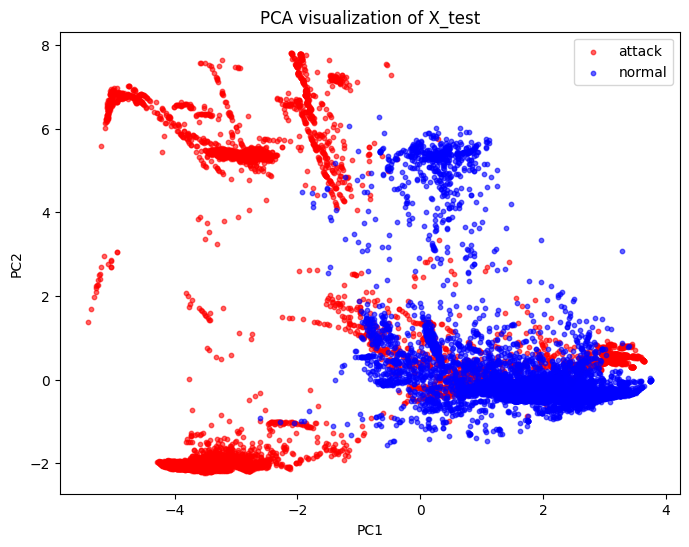

In [12]:
from sklearn.decomposition import PCA
y = y_test.flatten()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[y==0,0], X_pca[y==0,1], c='red', label='attack', alpha=0.6, s=10)
plt.scatter(X_pca[y==1,0], X_pca[y==1,1], c='blue', label='normal', alpha=0.6, s=10)
plt.legend()
plt.title('PCA visualization of X_test')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

##### (c) Use KernelPCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. Use radial basis function (rbf) as the kernel. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

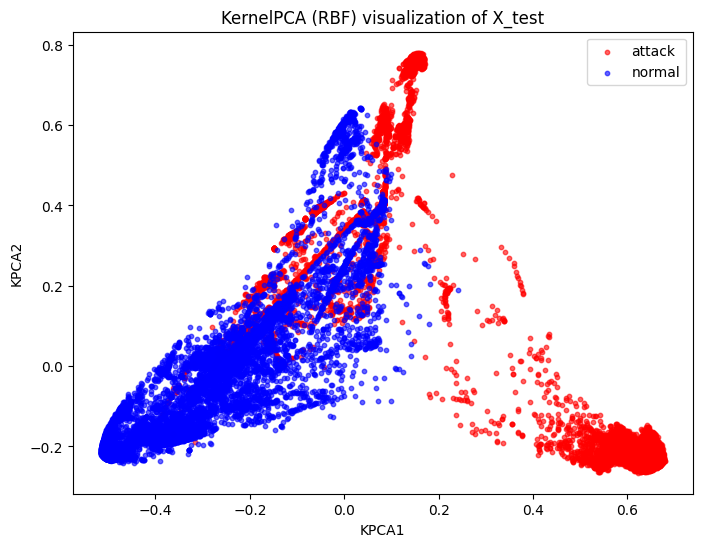

In [13]:
from sklearn.decomposition import KernelPCA
y = y_test.flatten()
kpca = KernelPCA(n_components=2, kernel='rbf')
X_kpca = kpca.fit_transform(X_test)

plt.figure(figsize=(8,6))
plt.scatter(X_kpca[y==0,0], X_kpca[y==0,1], c='red', label='attack', alpha=0.6, s=10)
plt.scatter(X_kpca[y==1,0], X_kpca[y==1,1], c='blue', label='normal', alpha=0.6, s=10)
plt.legend()
plt.title('KernelPCA (RBF) visualization of X_test')
plt.xlabel('KPCA1')
plt.ylabel('KPCA2')
plt.show()

## Question 3: Implementing a DNN on the dataset

##### (a) Implement a deep neural network (DNN) on the Network Anomaly Dataset. Ensure to include two neurons and softmax activation in the output layer of your DNN.

In [14]:
base_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(2, activation='softmax')
])

##### (b) Compile and train your DNN model on the training set (X_train). Denote the trained model as base_model.

In [15]:
base_model.compile(optimizer=Adam(learning_rate=0.001),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

history = base_model.fit(X_train, y_train,
                         epochs=20,
                         batch_size=64,
                         validation_split=0.1,
                         verbose=2)

Epoch 1/20
1418/1418 - 2s - loss: 0.0329 - accuracy: 0.9885 - val_loss: 0.0122 - val_accuracy: 0.9963 - 2s/epoch - 1ms/step
Epoch 2/20
1418/1418 - 1s - loss: 0.0097 - accuracy: 0.9965 - val_loss: 0.0094 - val_accuracy: 0.9962 - 1s/epoch - 814us/step
Epoch 3/20
1418/1418 - 1s - loss: 0.0073 - accuracy: 0.9971 - val_loss: 0.0089 - val_accuracy: 0.9964 - 1s/epoch - 804us/step
Epoch 4/20
1418/1418 - 1s - loss: 0.0063 - accuracy: 0.9974 - val_loss: 0.0115 - val_accuracy: 0.9955 - 1s/epoch - 838us/step
Epoch 5/20
1418/1418 - 1s - loss: 0.0053 - accuracy: 0.9980 - val_loss: 0.0062 - val_accuracy: 0.9978 - 1s/epoch - 802us/step
Epoch 6/20
1418/1418 - 1s - loss: 0.0048 - accuracy: 0.9983 - val_loss: 0.0074 - val_accuracy: 0.9969 - 1s/epoch - 806us/step
Epoch 7/20
1418/1418 - 1s - loss: 0.0047 - accuracy: 0.9983 - val_loss: 0.0065 - val_accuracy: 0.9974 - 1s/epoch - 807us/step
Epoch 8/20
1418/1418 - 1s - loss: 0.0038 - accuracy: 0.9987 - val_loss: 0.0052 - val_accuracy: 0.9980 - 1s/epoch - 858us

##### (c) Evaluate the base_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

In [16]:
y_prob = base_model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)
y_true = y_test.flatten()

print('Confusion Matrix:')
print(confusion_matrix(y_true, y_pred))
print('\nClassification Report:')
print(classification_report(y_true, y_pred))

788/788 [==============================] - 1s 671us/step
Confusion Matrix:
[[11684    20]
 [   13 13478]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11704
           1       1.00      1.00      1.00     13491

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



In [17]:
# Save the original Keras model to HDF5 file
base_model.save('original_model.h5')

## Question 4: Implementing Quantized Model

##### (a) Implement Dynamic Range Quantization on the base_model. Designate the resulting quantized ML model as tflite_quant_model.
Note: Implemented as full integer quantization instead of dynamic range quantization.

In [18]:
# Load the trained model
def representative_data_gen():
    for i in range(100):
        yield [X_train[i].astype(np.float32).reshape(1, 38)]

base_model = tf.keras.models.load_model('original_model.h5')

converter = tf.lite.TFLiteConverter.from_keras_model(base_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

tflite_quant_model = converter.convert()

INFO:tensorflow:Assets written to: /tmp/tmp9sohh5ib/assets


INFO:tensorflow:Assets written to: /tmp/tmp9sohh5ib/assets
2026-05-30 11:12:07.371685: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-30 11:12:07.371709: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-30 11:12:07.371923: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp9sohh5ib
2026-05-30 11:12:07.372544: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-30 11:12:07.372554: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp9sohh5ib
2026-05-30 11:12:07.374794: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-05-30 11:12:07.375599: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-30 11:12:07.406654: I tensorflow/cc/saved_model/loader.cc:217] Running initializatio

In [19]:
import os

# Save the quantized model
with open('quantized_model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

# Get the file sizes
original_model_size = os.path.getsize('original_model.h5')
quantized_model_size = os.path.getsize('quantized_model.tflite')

# Print the model sizes
print(f"Original model size: {original_model_size / 1024:.2f} KB")
print(f"Quantized model size: {quantized_model_size / 1024:.2f} KB")

Original model size: 84.05 KB
Quantized model size: 7.60 KB


##### (b) Evaluate the tflite_quant_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

In [20]:
## Evaluate the TFLite quantized model on X_test using the TFLite interpreter
interpreter = tf.lite.Interpreter(model_content=tflite_quant_model)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

preds = []
for i in range(X_test.shape[0]):
    # Prepare a single-sample batch and cast to the interpreter's expected dtype
    input_dtype = input_details[0]['dtype']
    sample = X_test[i:i+1].astype(input_dtype)
    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    pred_label = int(np.argmax(output_data, axis=1)[0])
    preds.append(pred_label)

y_true = y_test.flatten()
print('Confusion Matrix (TFLite quantized):')
print(confusion_matrix(y_true, preds))
print('\nClassification Report (TFLite quantized):')
print(classification_report(y_true, preds))

Confusion Matrix (TFLite quantized):
[[11685    19]
 [   19 13472]]

Classification Report (TFLite quantized):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11704
           1       1.00      1.00      1.00     13491

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## Converting tflite_model to C and create the header file

In [21]:
# c_writer is a py file in the same folder and has been imported at the beginning of the notebook
# Reference : https://github.com/ShawnHymel/tinyml-example-anomaly-detection/blob/master/utils/c_writer.py
# We use #04x to pad the output to 2 digits with a 0x prefix
hex_array = [format(val, '#04x') for val in tflite_quant_model]
# Calling function to convert an array into a C string (requires Numpy)
# create_array(np_array, var_type, var_name, line_limit=80, indent=4)
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")
# Calling Function to create a header file with given C code as a string
header_str = c_writer.create_header(c_model, "network_model")

In [22]:
#Writing to the header file
with open('network_model.h', 'w') as file:
    file.write(header_str)

## Generating Samples for Inference on Arduino

In [25]:
# Converting a sample piece of the X test and y test data to C (for the purpose of ino code (arduino) to load and test
# the sample and compare

Xtest = X_test[5:15,:]
print(c_writer.create_array(Xtest,"float","X_test"))

const unsigned int X_test_dim1 = 10;
const unsigned int X_test_dim2 = 38;

const float X_test[10][38] = {
    -0.11024922321249885, -0.12470615670462065, 1.0873051789289023, 
    -0.7362346401101137, -0.00776224074056876, -0.004918644383724874, 
    -0.08948642202040107, -0.09507567152556495, -0.8092618187059747, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    0.31344881836880206, -0.24420394625771188, 1.602663889932865, 
    1.6051037177847889, -0.37436223991967527, -0.37443160310530493, 
    -1.3214280114927377, -0.016929597707948767, -0.37455970440553465, 
    0.7343425609306344, -0.9453552789388989, -1.0719329252940557, 
    -0.12148518423158469, -0.4801968475158174, -0.28910340026287856, 
    1.6087590765792643, 1.6189552037455606, -0.38763462350750655, 
    -0.3763870260680415, 0.6528228780141483, -0.0998825

In [26]:
ytest=y_test[5:15]
print(c_writer.create_array(ytest,"uint8_t","y_test"))

const unsigned int y_test_dim1 = 10;
const unsigned int y_test_dim2 = 1;

const uint8_t y_test[10][1] = {
    0, 1, 1, 0, 0, 1, 0, 1, 0, 1
};

